In [1]:
import pandas as pd


In [2]:
degs_8W_F = pd.read_csv('/Users/derekebowman/Coding Projects/taPVAT_snRNAseq_analysis/code/scVelo_and_CellOracle/CellOracle/DEG_Data/taPVAT_Adipocytes_Brown_HF_8W_F_vs_Control_8W_F_diet_comparison_deseq_all_genes.txt', sep='\t')

In [3]:
predictions_8W_F = pd.read_csv('/Users/derekebowman/Coding Projects/taPVAT_snRNAseq_analysis/code/scVelo_and_CellOracle/CellOracle/scVIDR_Gene_Score_Predictions/August18_10_20_gene_scores_Adipocytes_Brown_8W_F.csv')

In [4]:
predictions_8W_F

,Unnamed: 0,Gene,Score
0,0,1700066B19Rik,-0.004412
1,1,6330411D24Rik,-0.074019
2,2,A2m,0.000815
3,3,AABR07000398.1,0.458759
4,4,AABR07001902.1,0.021668
...,...,...,...
4995,4995,Zp2,-0.030810
4996,4996,Zpbp,-0.005598
4997,4997,Zscan18,0.025793
4998,4998,Zswim6,-1.919915


In [5]:
predictions_8W_F = predictions_8W_F[~predictions_8W_F['Gene'].str.startswith('Mt-')] # Removed mitochondrial genes
predictions_8W_F = predictions_8W_F[~predictions_8W_F['Gene'].str.startswith('AABR')]
predictions_8W_F = predictions_8W_F[~predictions_8W_F['Gene'].str.startswith('ENSRN')]

In [6]:
degs_8W_F = degs_8W_F[degs_8W_F['padj'] <= 0.05]
degs_8W_F = degs_8W_F[~degs_8W_F['gene_id'].str.startswith('Mt-')] # Removed mitochondrial genes
degs_8W_F = degs_8W_F[~degs_8W_F['gene_id'].str.startswith('AABR')]
degs_8W_F = degs_8W_F[~degs_8W_F['gene_id'].str.startswith('ENSRN')]

degs_8W_F

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,celltype,group,group1,group2
96,AC096301.1,164.568517,2.531638,0.339149,7.464689,8.349681e-14,1.199446e-11,AC096301.1,Adipocytes_Brown,diet,Control,HF
100,AC115369.1,17.497857,-2.847191,0.715473,-3.979456,6.907321e-05,1.409307e-03,AC115369.1,Adipocytes_Brown,diet,Control,HF
106,AC125757.1,279.035502,2.947956,0.299614,9.839195,7.631915e-23,3.752847e-20,AC125757.1,Adipocytes_Brown,diet,Control,HF
114,Aak1,1203.900265,-0.503111,0.167339,-3.006532,2.642459e-03,2.573026e-02,Aak1,Adipocytes_Brown,diet,Control,HF
120,Aarsd1,208.144465,0.578238,0.205662,2.811597,4.929621e-03,4.095205e-02,Aarsd1,Adipocytes_Brown,diet,Control,HF
...,...,...,...,...,...,...,...,...,...,...,...,...
12686,Zfyve1,1122.426728,-0.647974,0.183806,-3.525321,4.229693e-04,6.238741e-03,Zfyve1,Adipocytes_Brown,diet,Control,HF
12710,Zmat5,117.571337,-0.926515,0.279464,-3.315321,9.153782e-04,1.128554e-02,Zmat5,Adipocytes_Brown,diet,Control,HF
12730,Znf740,414.279013,0.619714,0.193724,3.198952,1.379283e-03,1.578705e-02,Znf740,Adipocytes_Brown,diet,Control,HF
12774,Zwint,142.130699,-1.016179,0.262881,-3.865539,1.108439e-04,2.096360e-03,Zwint,Adipocytes_Brown,diet,Control,HF


In [7]:
degs_up_in_HF = degs_8W_F[degs_8W_F['log2FoldChange'] >= 1.0]
degs_down_in_HF = degs_8W_F[degs_8W_F['log2FoldChange'] <= -1.0]

In [8]:
upregulated_predictions_8W_F = predictions_8W_F[predictions_8W_F['Gene'].isin(list(degs_up_in_HF['gene_id']))]
downregulated_predictions_8W_F = predictions_8W_F[predictions_8W_F['Gene'].isin(list(degs_down_in_HF['gene_id']))]

In [9]:
gene_to_logfc = degs_8W_F.set_index('gene_id')['log2FoldChange']
downregulated_predictions_8W_F['GroundTruthLog2FC'] = downregulated_predictions_8W_F['Gene'].map(gene_to_logfc)
upregulated_predictions_8W_F['GroundTruthLog2FC'] = upregulated_predictions_8W_F['Gene'].map(gene_to_logfc)


/var/folders/3v/fv2nh3dj3z9b9bkz4lcmhvq80000gn/T/ipykernel_49826/700238669.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downregulated_predictions_8W_F['GroundTruthLog2FC'] = downregulated_predictions_8W_F['Gene'].map(gene_to_logfc)
/var/folders/3v/fv2nh3dj3z9b9bkz4lcmhvq80000gn/T/ipykernel_49826/700238669.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upregulated_predictions_8W_F['GroundTruthLog2FC'] = upregulated_predictions_8W_F['Gene'].map(gene_to_logfc)


In [10]:
upregulated_predictions_8W_F.sort_values(by='Score', inplace=True, ascending=False)
downregulated_predictions_8W_F.sort_values(by='Score', inplace=True, ascending=True)

/var/folders/3v/fv2nh3dj3z9b9bkz4lcmhvq80000gn/T/ipykernel_49826/2177056150.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upregulated_predictions_8W_F.sort_values(by='Score', inplace=True, ascending=False)
/var/folders/3v/fv2nh3dj3z9b9bkz4lcmhvq80000gn/T/ipykernel_49826/2177056150.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downregulated_predictions_8W_F.sort_values(by='Score', inplace=True, ascending=True)


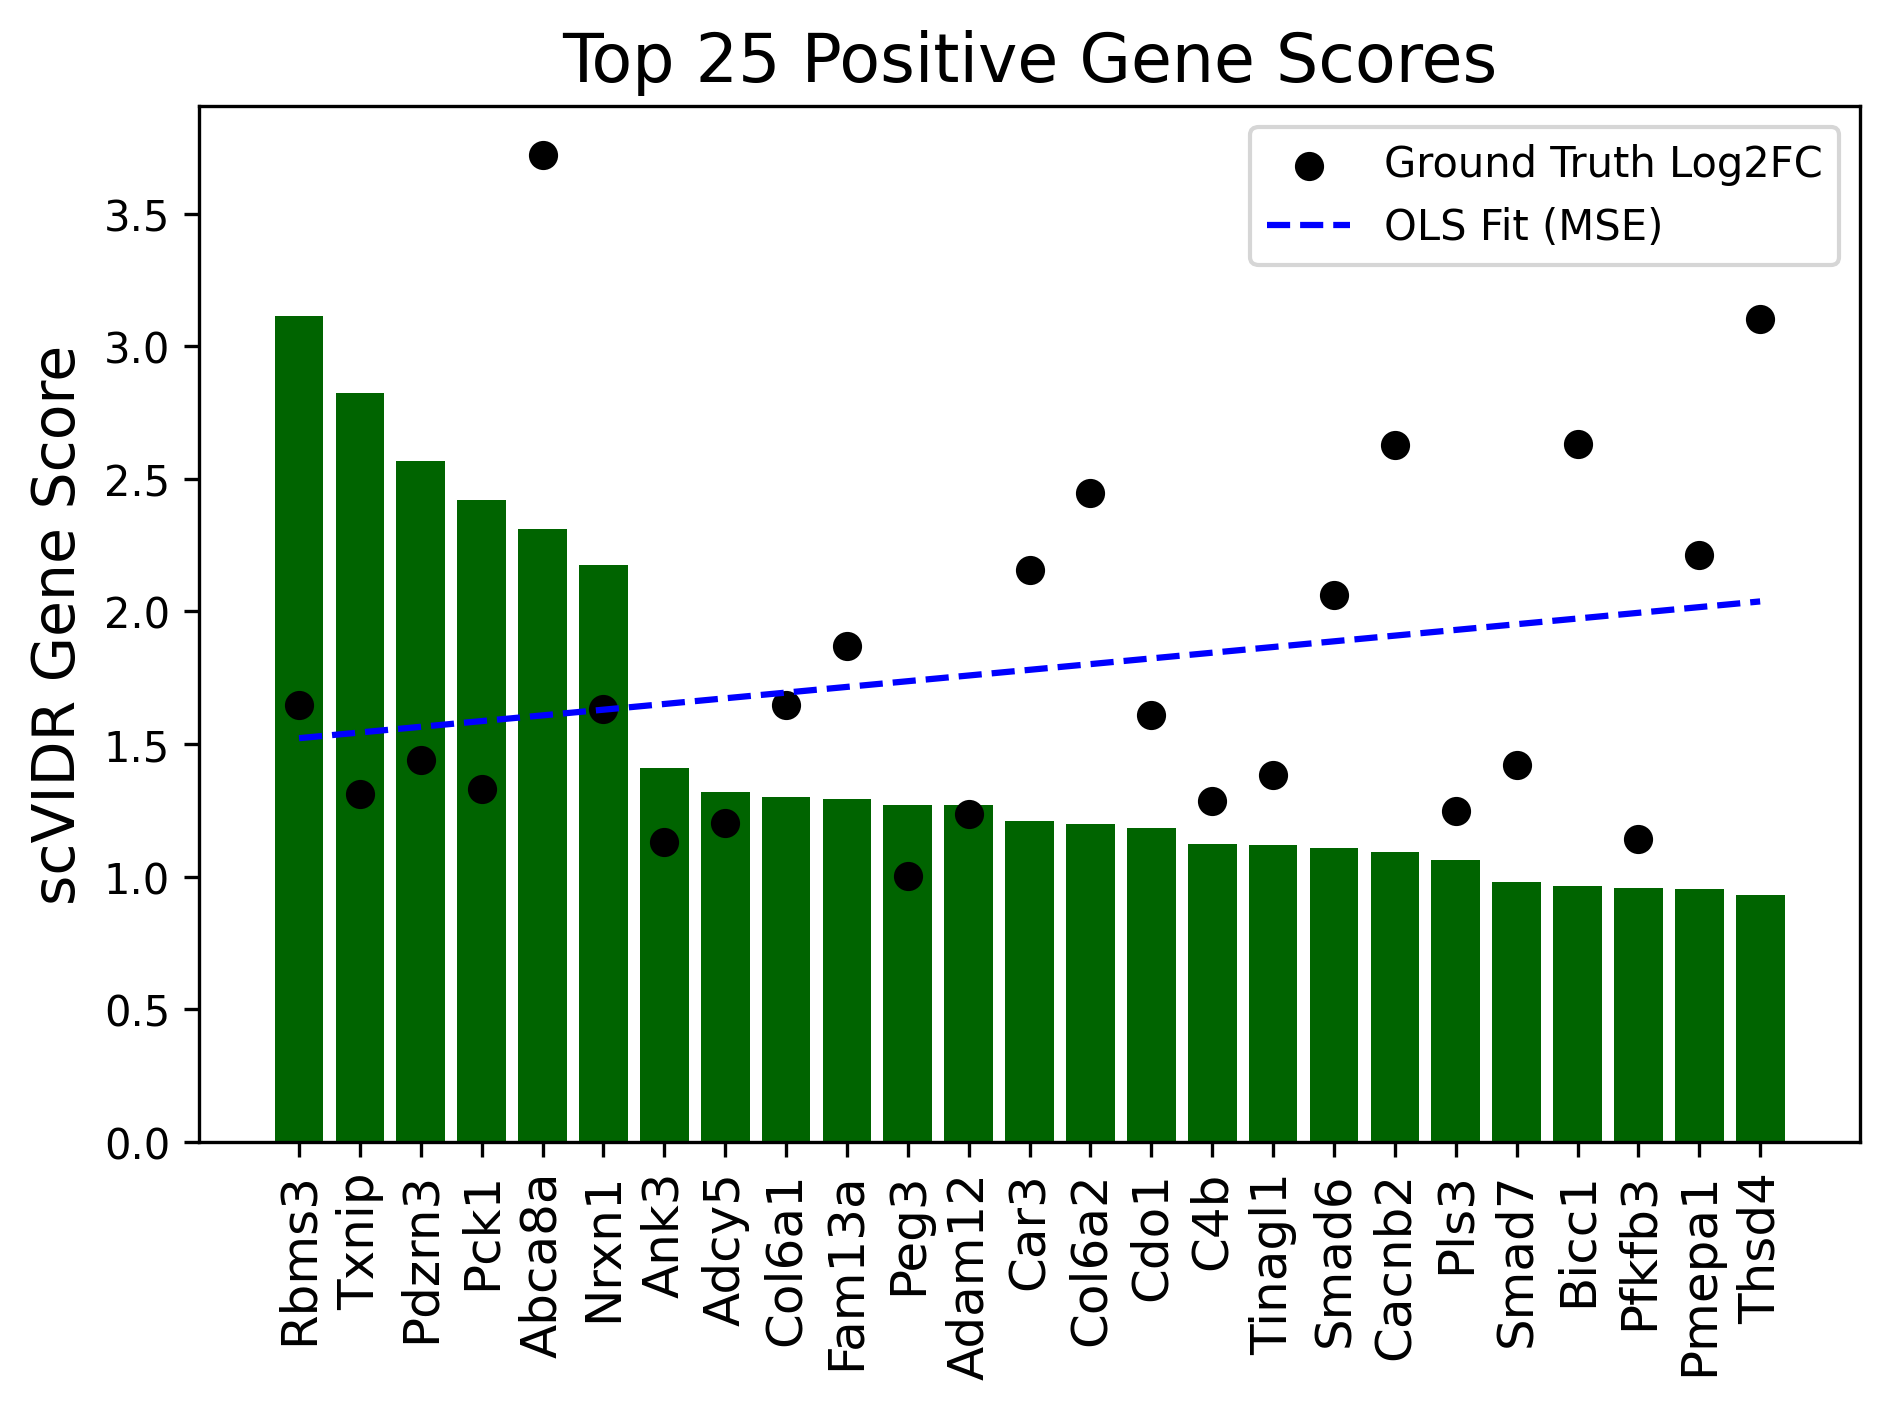

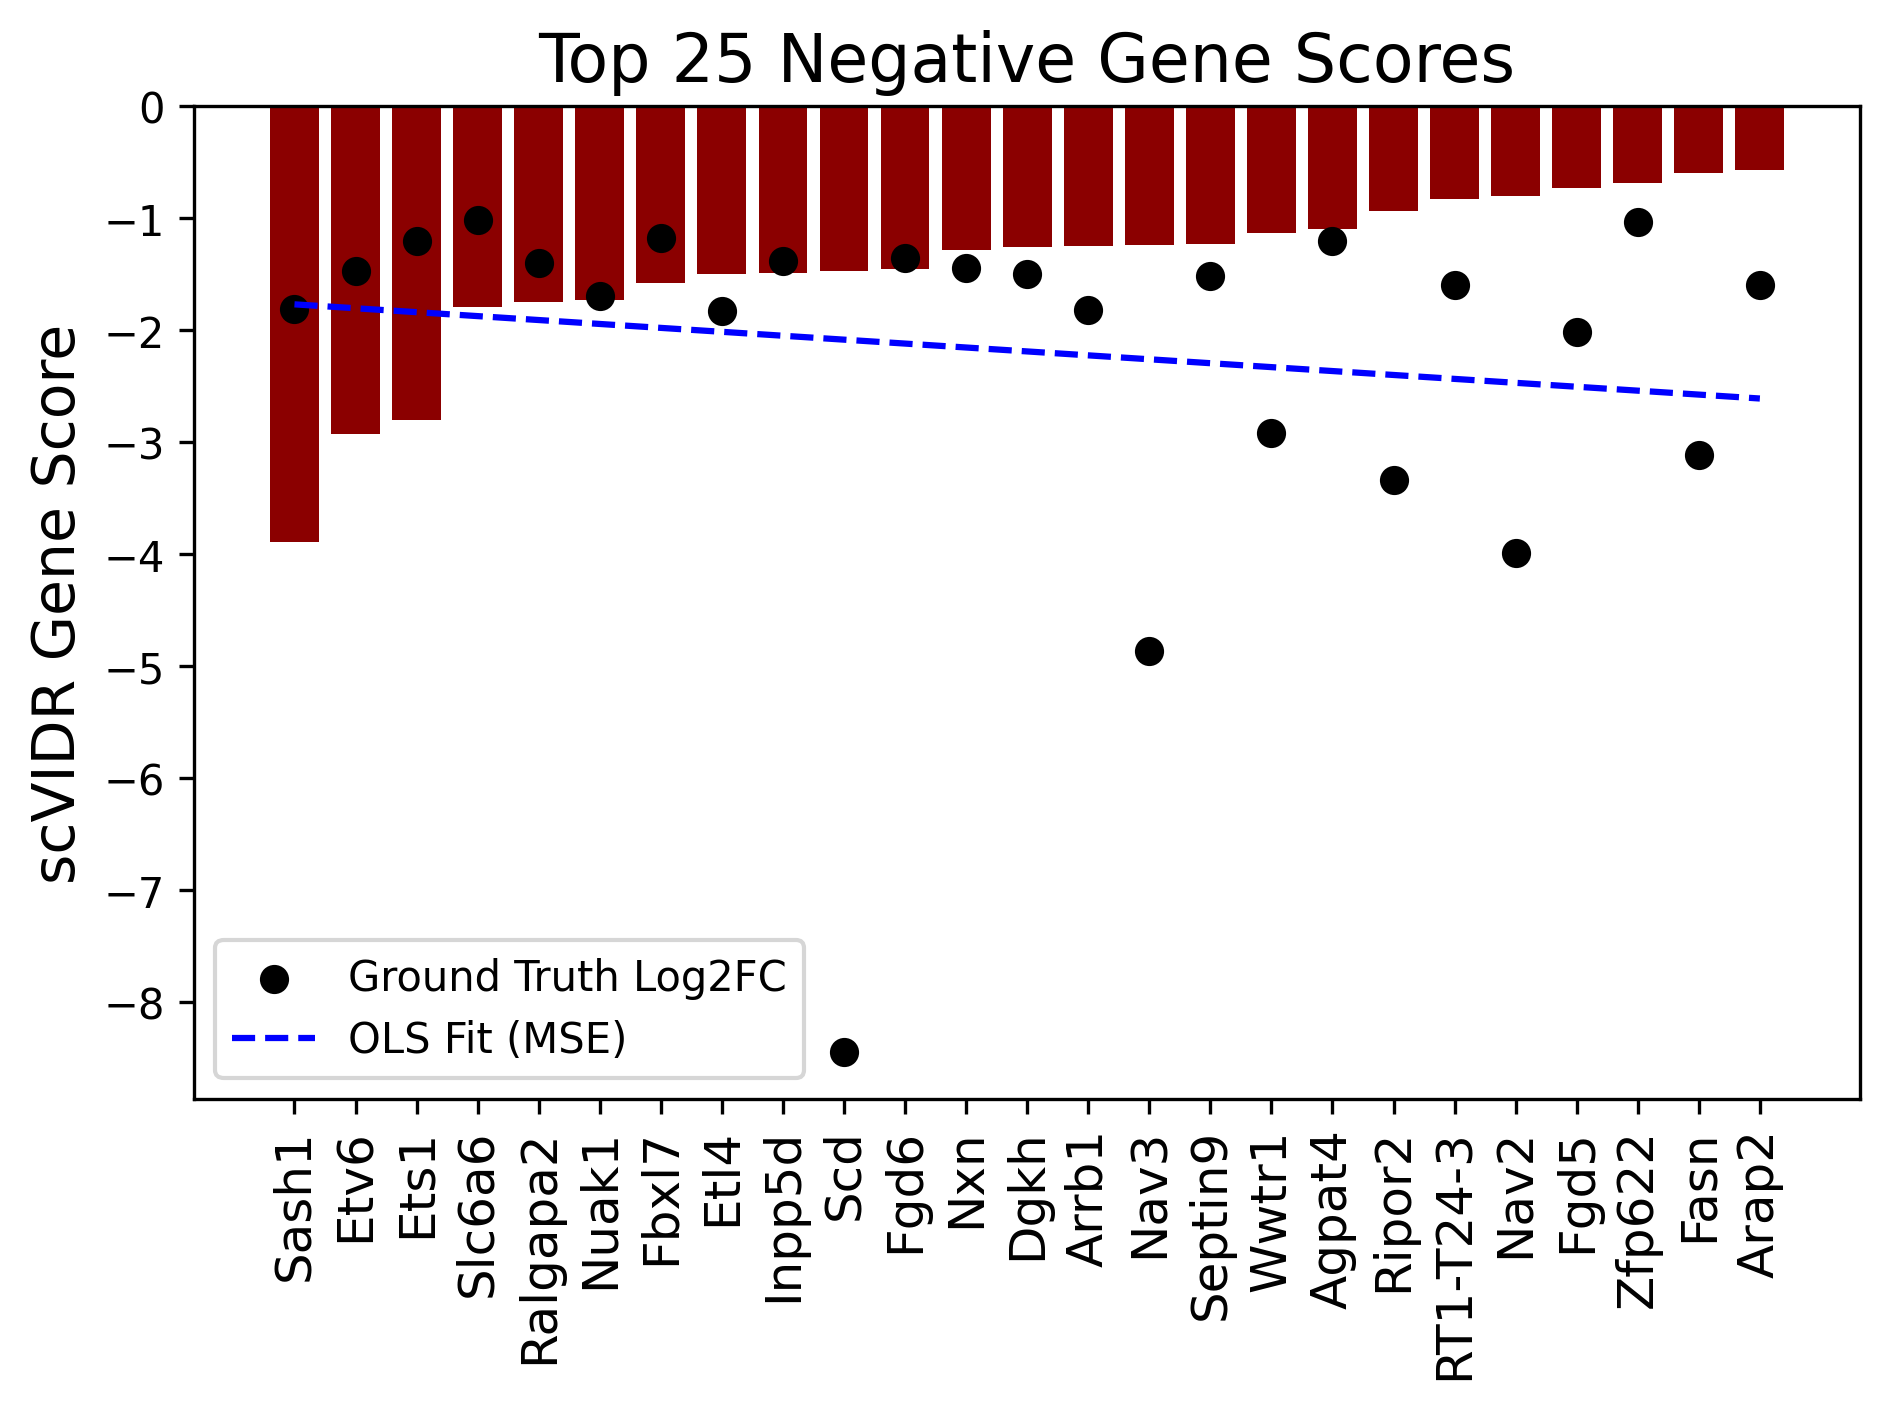

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression


# Top 25 most positive gene scores
top_pos = upregulated_predictions_8W_F.head(25)

plt.figure(dpi=300)
plt.bar(top_pos['Gene'], top_pos['Score'], color='darkgreen')
plt.scatter(top_pos['Gene'], top_pos['GroundTruthLog2FC'], color='black', label='Ground Truth Log2FC')



X = np.arange(len(top_pos['Gene'])).reshape(-1, 1)
y = top_pos['GroundTruthLog2FC'].values


ols = LinearRegression()
ols.fit(X, y)

y_pred = ols.predict(X)






plt.plot(top_pos['Gene'], y_pred, color='blue', linestyle='--', label='OLS Fit (MSE)')
plt.legend()

plt.xticks(rotation=90, fontsize=12)
plt.ylabel("scVIDR Gene Score", fontsize=14)
plt.title("Top 25 Positive Gene Scores", fontsize=16)
plt.tight_layout()
#plt.savefig("../figures/Top25PositiveGeneScores_24W_Brown_Adipocytes_Both.svg", bbox_inches="tight")
plt.show()




# Top 25 most negative gene scores
top_neg = downregulated_predictions_8W_F.head(25)
plt.figure(dpi=300)
plt.bar(top_neg['Gene'], top_neg['Score'], color='darkred')
plt.scatter(top_neg['Gene'], top_neg['GroundTruthLog2FC'], color='black', label='Ground Truth Log2FC')


X = np.arange(len(top_neg['Gene'])).reshape(-1, 1)
y = top_neg['GroundTruthLog2FC'].values


ols = LinearRegression()
ols.fit(X, y)

y_pred = ols.predict(X)

plt.plot(top_neg['Gene'], y_pred, color='blue', linestyle='--', label='OLS Fit (MSE)')
    
plt.xticks(rotation=90, fontsize=12)
plt.ylabel("scVIDR Gene Score", fontsize=14)
plt.title("Top 25 Negative Gene Scores", fontsize=16)
plt.legend()
plt.tight_layout()
#plt.savefig("../figures/Top25NegativeGeneScores_24W_Brown_Adipocytes_Both.svg", bbox_inches="tight")
plt.show()
